最新数据日期：2023-08-17
             open   high    low  close     volume
2023-08-11  67.30  68.40  65.50  65.58  1277900.0
2023-08-14  65.08  65.97  62.81  64.64  2270947.0
2023-08-15  64.90  64.90  62.13  62.60  1572996.0
2023-08-16  62.30  64.69  62.30  64.35  2126613.0
2023-08-17  64.14  65.40  63.60  65.02  1005681.0


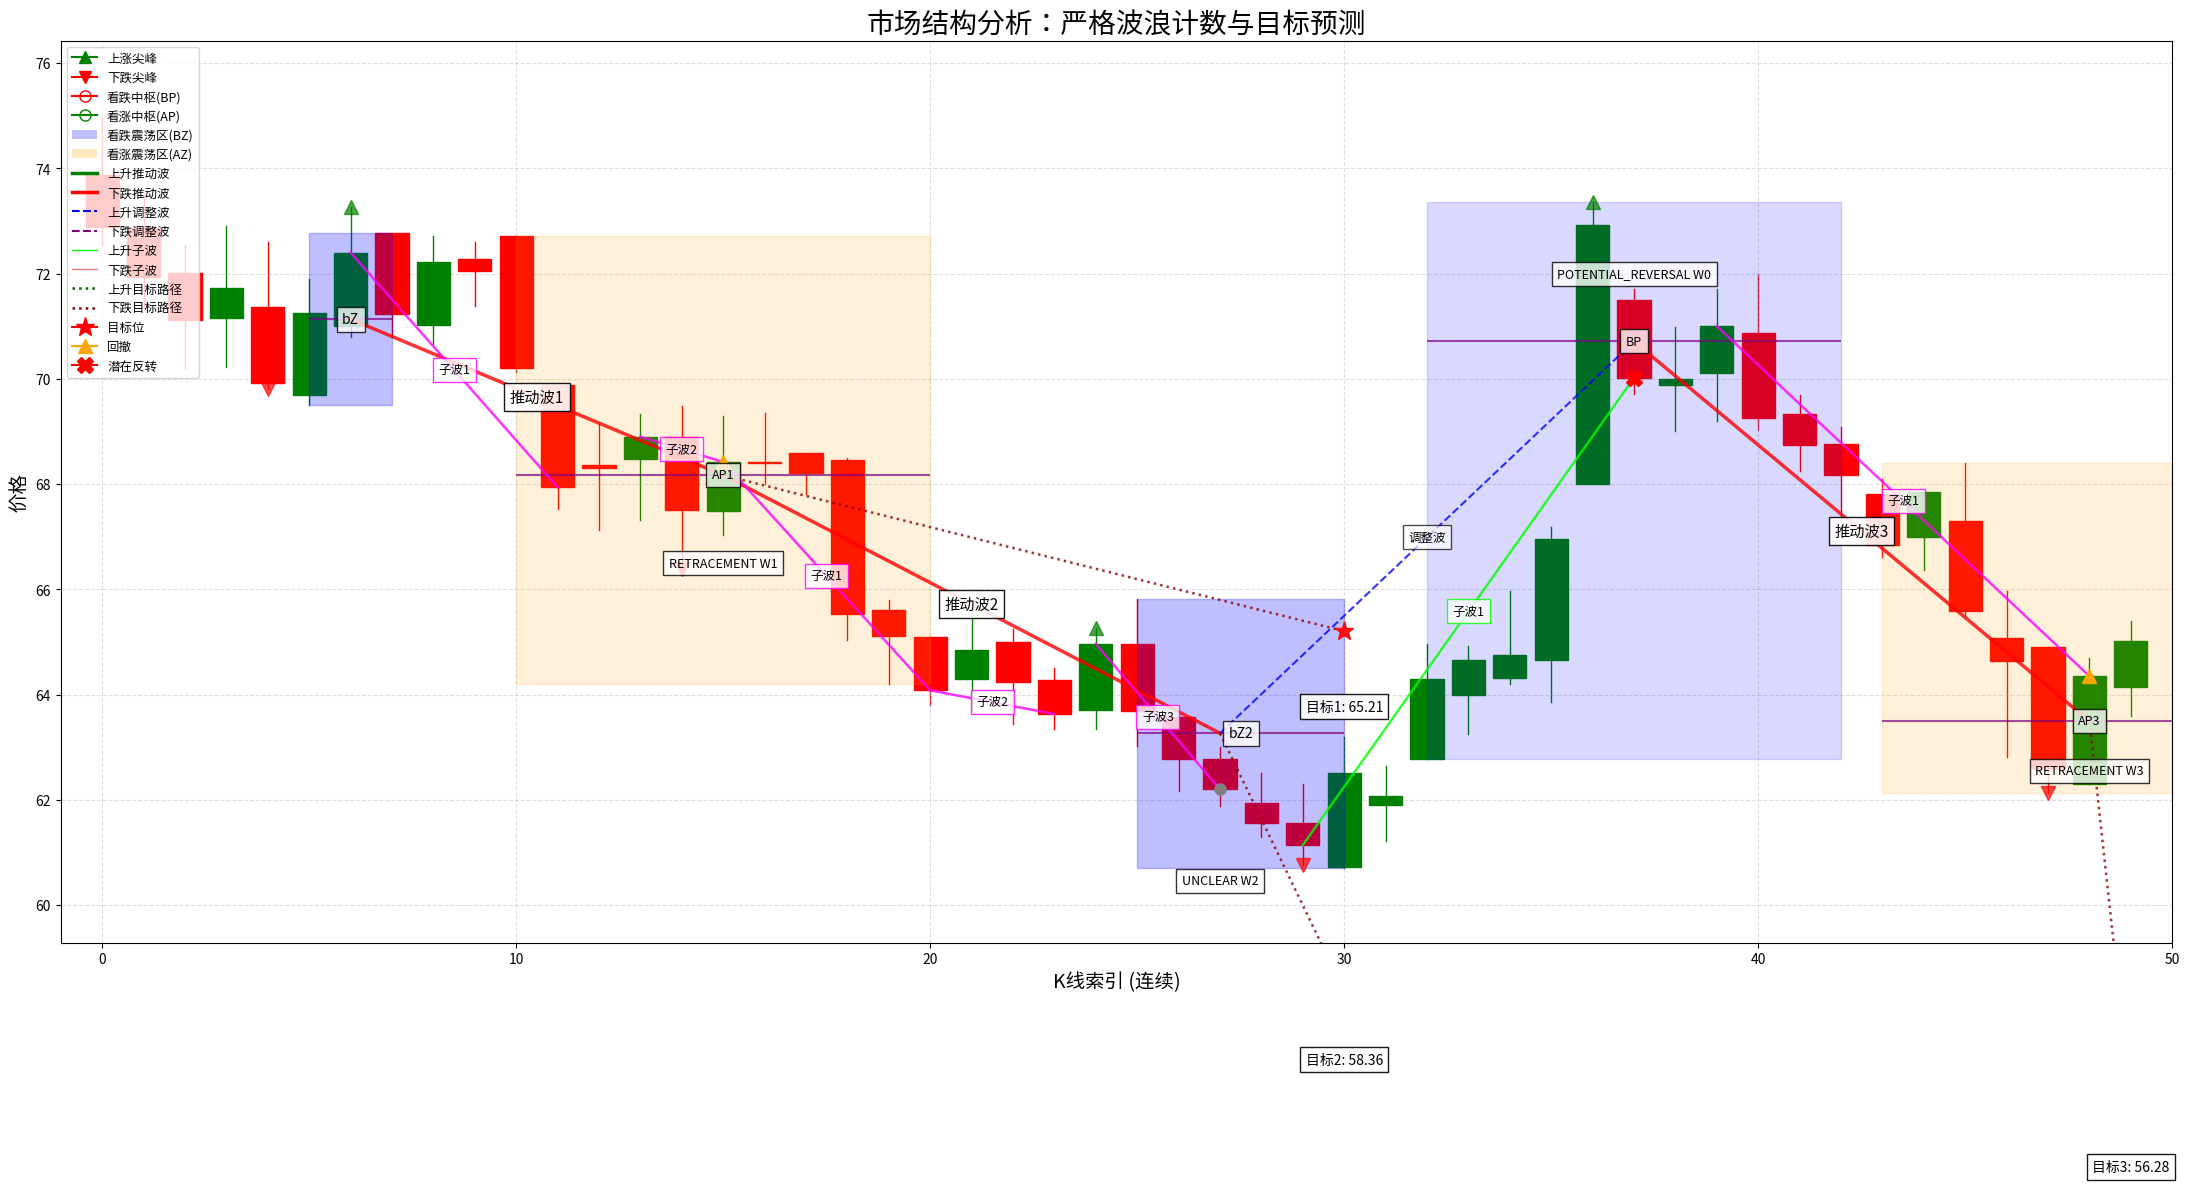

In [7]:
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import argparse
import datetime
import numpy as np
from scipy.signal import find_peaks
import pandas as pd
from matplotlib.dates import DateFormatter
from scipy import cluster
import matplotlib.dates as mdates
from numpy.lib.stride_tricks import sliding_window_view
import argparse
import datetime
from scipy.signal import argrelextrema
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from scipy.cluster import hierarchy
from scipy.stats import linregress
import numpy as np
from scipy.spatial.distance import mahalanobis
from scipy.cluster import hierarchy
from sklearn.covariance import EmpiricalCovariance
from scipy.linalg import pinv

import numpy as np
from scipy.spatial.distance import mahalanobis
from sklearn.covariance import EmpiricalCovariance
from scipy.linalg import pinv

import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

def detect_pivot_points(df, distance_threshold=7, height_threshold=0.007):
    """检测关键枢轴点（尖峰后的第一根异性K棒），合并相邻且高度相近的峰值"""
    close = df['close'].values
    open_ = df['open'].values
    high = df['high'].values
    low = df['low'].values
    
    # 1. 检测上涨尖峰（局部高点）
    up_peaks = argrelextrema(close, np.greater, order=3)[0]
    
    # 2. 检测下跌极点（局部低点）
    down_peaks = argrelextrema(close, np.less, order=3)[0]
    
    # 3. 合并相邻且高度相近的峰值
    merged_up_peaks = []
    merged_down_peaks = []
    
    # 合并上涨尖峰
    i = 0
    while i < len(up_peaks):
        current_peak = up_peaks[i]
        group = [current_peak]
        j = i + 1
        
        # 寻找相邻的峰值
        while j < len(up_peaks) and (up_peaks[j] - current_peak) <= distance_threshold:
            group.append(up_peaks[j])
            j += 1
        
        # 在组内找到最高点
        highest_idx = group[0]
        for idx in group:
            if high[idx] > high[highest_idx]:
                highest_idx = idx
        
        # 检查高度是否相近
        min_height = min(high[idx] for idx in group)
        max_height = max(high[idx] for idx in group)
        height_diff = (max_height - min_height) / min_height
        
        if height_diff <= height_threshold:
            merged_up_peaks.append(highest_idx)
        else:
            # 高度差异大，保留所有点
            merged_up_peaks.extend(group)
        
        i = j
    
    # 合并下跌极点
    i = 0
    while i < len(down_peaks):
        current_peak = down_peaks[i]
        group = [current_peak]
        j = i + 1
        
        # 寻找相邻的峰值
        while j < len(down_peaks) and (down_peaks[j] - current_peak) <= distance_threshold:
            group.append(down_peaks[j])
            j += 1
        
        # 在组内找到最低点
        lowest_idx = group[0]
        for idx in group:
            if low[idx] < low[lowest_idx]:
                lowest_idx = idx
        
        # 检查高度是否相近
        min_height = min(low[idx] for idx in group)
        max_height = max(low[idx] for idx in group)
        height_diff = (max_height - min_height) / min_height
        
        if height_diff <= height_threshold:
            merged_down_peaks.append(lowest_idx)
        else:
            # 高度差异大，保留所有点
            merged_down_peaks.extend(group)
        
        i = j
    
    # 4. 检测中枢棒（尖峰后第一根反向K棒）
    pivot_bars = []
    
    # 处理上涨尖峰
    for peak_idx in merged_up_peaks:
        # 寻找尖峰后第一根阴棒（收盘<开盘）
        for i in range(peak_idx + 1, min(peak_idx + 10, len(df))):
            if close[i] < open_[i]:  # 阴线
                pivot_bar = {
                    'index': i,
                    'type': 'bearish_pivot',
                    'peak_index': peak_idx,
                    'price': (high[i] + low[i]) / 2,
                    'high': high[i],
                    'low': low[i],
                    'date': df.index[i]
                }
                pivot_bars.append(pivot_bar)
                break
    
    # 处理下跌尖峰
    for trough_idx in merged_down_peaks:
        # 寻找尖峰后第一根阳棒（收盘>开盘）
        for i in range(trough_idx + 1, min(trough_idx + 10, len(df))):
            if close[i] > open_[i]:  # 阳线
                pivot_bar = {
                    'index': i,
                    'type': 'bullish_pivot',
                    'peak_index': trough_idx,
                    'price': (high[i] + low[i]) / 2,
                    'high': high[i],
                    'low': low[i],
                    'date': df.index[i]
                }
                pivot_bars.append(pivot_bar)
                break
    
    # 对枢轴点按索引排序
    pivot_bars.sort(key=lambda x: x['index'])
    
    return merged_up_peaks, merged_down_peaks, pivot_bars
   

def cluster_pivot_points(pivot_bars, max_distance=5):
    """聚类相邻的BP和AP，识别震荡区间作为中枢"""
    if len(pivot_bars) < 2:
        return [], pivot_bars
    
    # 按索引排序枢轴点
    pivot_bars = sorted(pivot_bars, key=lambda x: x['index'])
    
    # 提取索引用于聚类
    indices = np.array([p['index'] for p in pivot_bars]).reshape(-1,1)
    if len(pivot_bars) < 2:
        return [], pivot_bars
    
    # 按索引排序枢轴点
    pivot_bars = sorted(pivot_bars, key=lambda x: x['index'])
    
    # 提取索引用于聚类
    indices = np.array([p['index'] for p in pivot_bars]).reshape(-1, 1)
    
    # 使用层次聚类
    clusters = cluster.hierarchy.fclusterdata(
        indices, 
        t=max_distance, 
        criterion='distance', 
        metric='euclidean', 
        method='single'
    )
    
    # 组织聚类结果
    clustered_zones = []
    non_clustered = []
    
    for cluster_id in np.unique(clusters):
        cluster_points = [p for i, p in enumerate(pivot_bars) if clusters[i] == cluster_id]
        
        # 如果聚类中只有一个点，则视为非震荡中枢
        if len(cluster_points) == 1:
            non_clustered.append(cluster_points[0])
            continue
        
        # 创建震荡中枢
        start_idx = min(p['index'] for p in cluster_points)
        end_idx = max(p['index'] for p in cluster_points)
        high = max(p['high'] for p in cluster_points)
        low = min(p['low'] for p in cluster_points)
        center = (high + low) / 2
        
        # 确定震荡中枢类型
        bullish_count = sum(1 for p in cluster_points if p['type'] == 'bullish_pivot')
        bearish_count = sum(1 for p in cluster_points if p['type'] == 'bearish_pivot')
        pivot_type = 'bullish' if bullish_count > bearish_count else 'bearish'
        
        clustered_zones.append({
            'start_idx': start_idx,
            'end_idx': end_idx,
            'high': high,
            'low': low,
            'center': center,
            'points': cluster_points,
            'type': pivot_type + '_zone',  # 如 'bullish_zone'
            'index': (start_idx + end_idx) // 2,  # 中枢中心位置
            'price': center,
            'date': cluster_points[len(cluster_points)//2]['date']  # 取中间点的日期
        })
    
    return clustered_zones, non_clustered


def detect_subwaves_by_slope(df, start_idx, end_idx, min_wave_length=2, slope_threshold=0.005, wave_number_start=1):
    """
    改进子波检测：使用更灵敏的极值点检测方法，确保波数连续
    """
    # 检查波段长度
    if end_idx <= start_idx or end_idx - start_idx < min_wave_length * 2:
        direction = 'up' if df['close'].iloc[end_idx] > df['close'].iloc[start_idx] else 'down'
        return [{
            'start': start_idx,
            'end': end_idx,
            'direction': direction,
            'wave_number': wave_number_start
        }]
    
    # 提取波段数据
    segment = df.iloc[start_idx:end_idx+1]
    prices = segment['close'].values
    
    # 1. 确定整体方向
    overall_direction = 1 if prices[-1] > prices[0] else -1
    
    # 2. 寻找波段内的主要转折点（改进的极值点检测）
    peaks = []
    troughs = []
    
    # 使用更灵敏的极值点检测
    for i in range(1, len(prices)-1):
        # 检测局部高点：比前2根和后2根都高
        if i >= 2 and i < len(prices)-2:
            if prices[i] > max(prices[i-2], prices[i-1]) and prices[i] > max(prices[i+1], prices[i+2]):
                peaks.append(i)
        
        # 检测局部低点：比前2根和后2根都低
        if i >= 2 and i < len(prices)-2:
            if prices[i] < min(prices[i-2], prices[i-1]) and prices[i] < min(prices[i+1], prices[i+2]):
                troughs.append(i)
    
    # 3. 添加更严格的转折点筛选
    filtered_points = []
    
    # 确保转折点之间有足够的价格变化
    for point in sorted(peaks + troughs):
        if not filtered_points:
            filtered_points.append(point)
            continue
            
        last_point = filtered_points[-1]
        price_change = abs(prices[point] - prices[last_point]) / prices[last_point]
        
        # 只保留价格变化超过阈值的转折点
        if price_change > slope_threshold:
            filtered_points.append(point)
    
    # 4. 合并起点、终点和过滤后的极值点
    all_points = sorted([0] + filtered_points + [len(prices)-1])
    
    # 5. 创建子波（只保留与整体方向一致的波段）
    subwaves = []
    wave_number = wave_number_start
    
    for i in range(1, len(all_points)):
        start_i = all_points[i-1]
        end_i = all_points[i]
        
        # 确保波段有最小长度
        if end_i - start_i < min_wave_length:
            continue
            
        # 计算波段方向
        start_price = prices[start_i]
        end_price = prices[end_i]
        direction = 'up' if end_price > start_price else 'down'
        
        # 只保留与整体方向一致的波段
        if (overall_direction == 1 and direction == 'up') or (overall_direction == -1 and direction == 'down'):
            # 计算波段斜率
            slope = (end_price - start_price) / (end_i - start_i) if (end_i - start_i) > 0 else 0
            
            # 只保留斜率超过阈值的波段
            if abs(slope) > slope_threshold:
                subwaves.append({
                    'start': start_idx + start_i,
                    'end': start_idx + end_i,
                    'direction': direction,
                    'wave_number': wave_number,
                    'slope': slope
                })
                wave_number += 1
    
    # 6. 如果没有检测到子波，返回整个波段
    if not subwaves:
        direction = 'up' if prices[-1] > prices[0] else 'down'
        return [{
            'start': start_idx,
            'end': end_idx,
            'direction': direction,
            'wave_number': wave_number_start
        }]
    
    return subwaves



    
def create_zone(cluster_points):
    """从一组点创建震荡中枢"""
    # 提取关键信息
    indices = [p['index'] for p in cluster_points]
    prices = [p['price'] for p in cluster_points]
    highs = [p['high'] for p in cluster_points]
    lows = [p['low'] for p in cluster_points]
    
    # 计算区间边界
    start_idx = min(indices)
    end_idx = max(indices)
    high = max(highs)
    low = min(lows)
    center = (high + low) / 2
    
    # 计算价格重心（加权平均）
    weights = np.array([1.0] * len(prices))  # 等权重
    weighted_center = np.average(prices, weights=weights)
    
    # 计算价格变动范围百分比
    price_range_pct = (high - low) / low * 100
    
    # 确定震荡中枢类型
    bullish_count = sum(1 for p in cluster_points if p['type'] == 'bullish_pivot')
    bearish_count = sum(1 for p in cluster_points if p['type'] == 'bearish_pivot')
    pivot_type = 'bullish' if bullish_count > bearish_count else 'bearish'
    
    # 选择代表性日期（中间点）
    mid_index = sorted(indices)[len(indices)//2]
    rep_point = next(p for p in cluster_points if p['index'] == mid_index)
    
    return {
        'start_idx': start_idx,
        'end_idx': end_idx,
        'duration': end_idx - start_idx + 1,
        'high': high,
        'low': low,
        'price_range_pct': price_range_pct,
        'center': center,
        'weighted_center': weighted_center,
        'points': cluster_points,
        'type': pivot_type + '_zone',
        'index': (start_idx + end_idx) // 2,
        'price': weighted_center,
        'date': rep_point['date'],
        'bullish_count': bullish_count,
        'bearish_count': bearish_count
    }

def create_unified_pivots(clustered_zones, non_clustered):
    """创建统一的中枢列表（包括震荡中枢和非震荡中枢）并按时间排序"""
    # 转换非震荡中枢格式
    single_pivots = []
    for pivot in non_clustered:
        single_pivots.append({
            'type': pivot['type'] + '_pivot',
            'index': pivot['index'],
            'price': pivot['price'],
            'date': pivot['date'],
            'is_zone': False
        })
    
    # 转换震荡中枢格式
    zone_pivots = []
    for zone in clustered_zones:
        zone_pivots.append({
            'type': zone['type'],
            'index': zone['index'],
            'price': zone['price'],
            'date': zone['date'],
            'is_zone': True,
            'zone_data': zone  # 保留原始数据用于绘图
        })
    
    # 合并并排序
    all_pivots = single_pivots + zone_pivots
    all_pivots = sorted(all_pivots, key=lambda x: x['index'])
    
    return all_pivots

 
def calculate_wave_structure(pivots, df):
    """为中枢之间的运动分配波数（严格遵循波浪理论）"""
    if len(pivots) < 2:
        return pivots, []
    
    # 初始化波浪计数
    wave_count = 1
    wave_moves = []  # 存储波浪运动的详细信息
    trend_direction = None  # 当前趋势方向
    
    # 第一个中枢没有运动
    pivots[0]['wave'] = 0
    
    # 遍历中枢之间的运动
    for i in range(1, len(pivots)):
        prev_pivot = pivots[i-1]
        curr_pivot = pivots[i]
        
        # 确定运动方向
        if curr_pivot['price'] > prev_pivot['price']:
            move_direction = 'up'
        else:
            move_direction = 'down'
        
        # 确定运动类型
        if i == 1:
            # 第一个运动总是推动波
            move_type = 'impulse'
            wave_count = 1
            trend_direction = move_direction  # 设置趋势方向
        else:
            prev_move = wave_moves[-1]
            
            # 规则1: 连续两个调整波 -> 视为反转
            if prev_move['move_type'] == 'correction' and move_direction == prev_move['direction']:
                move_type = 'impulse'
                wave_count = 1
                trend_direction = move_direction  # 反转趋势
            
            # 规则2: 调整波->推动波->调整波 且价格突破
            elif (
                len(wave_moves) >= 2 and 
                wave_moves[-2]['move_type'] == 'correction' and 
                prev_move['move_type'] == 'impulse'
            ):
                first_correction = wave_moves[-2]  # 第一个调整波
                
                # 在上升趋势中：第二个调整波（下跌）必须创更低低点
                if trend_direction == 'up' and move_direction == 'down':
                    if curr_pivot['price'] < first_correction['end_pivot']['price']:
                        move_type = 'impulse'  # 视为反转
                        wave_count = 1
                        trend_direction = 'down'  # 更新为下跌趋势
                    else:
                        move_type = 'correction'
                
                # 在下跌趋势中：第二个调整波（上涨）必须创更高高点
                elif trend_direction == 'down' and move_direction == 'up':
                    if curr_pivot['price'] > first_correction['end_pivot']['price']:
                        move_type = 'impulse'  # 视为反转
                        wave_count = 1
                        trend_direction = 'up'  # 更新为上升趋势
                    else:
                        move_type = 'correction'
                else:
                    # 其他情况按正常规则处理
                    if move_direction == trend_direction:
                        move_type = 'impulse'
                        wave_count += 1
                    else:
                        move_type = 'correction'
            
            # 正常情况：同方向为推动波，反方向为调整波
            else:
                if move_direction == trend_direction:
                    move_type = 'impulse'
                    wave_count += 1
                else:
                    move_type = 'correction'
        
        # 检测子波
        subwaves = detect_subwaves_by_slope(df, prev_pivot['index'], curr_pivot['index'])
        
        # 记录波浪运动
        move_info = {
            'start_pivot': prev_pivot,
            'end_pivot': curr_pivot,
            'direction': move_direction,
            'wave_number': wave_count if move_type == 'impulse' else 0,
            'move_type': move_type,
            'subwaves': subwaves,
            'trend_direction': trend_direction
        }
        wave_moves.append(move_info)
        
        # 为当前中枢标记波数
        curr_pivot['wave'] = wave_count if move_type == 'impulse' else 0
    
    return pivots, wave_moves


def detect_trend_direction(wave_moves):
    """基于波浪运动识别市场主要趋势方向"""
    if len(wave_moves) == 0:
        return None
    return wave_moves[-1]['trend_direction']
   

def identify_measurement_moves(wave_moves, df):
    """识别波浪运动的测量目标"""
    measurements = []
    
    for move in wave_moves:
        # 只对推动波进行测量
        if move['move_type'] != 'impulse':
            continue
            
        start_pivot = move['start_pivot']
        end_pivot = move['end_pivot']
        wave_number = move['wave_number']
        direction = move['direction']
        
        # 计算运动距离
        distance = abs(end_pivot['price'] - start_pivot['price'])
        
        # 预测目标位
        if direction == 'up':
            target = end_pivot['price'] + distance
        else:
            target = end_pivot['price'] - distance
        
        # 找到实际突破点
        start_idx = end_pivot['index'] + 1
        if start_idx < len(df):
            # 对于上升趋势，寻找突破高点
            if direction == 'up':
                # 找到从突破点开始的新高
                high_prices = df['high'].iloc[start_idx:]
                if len(high_prices) > 0:
                    # 获取突破点的索引位置
                    breakout_idx = high_prices.idxmax()
                    # 确保是整数索引
                    if isinstance(breakout_idx, pd.Timestamp):
                        # 如果是时间戳，转换为整数位置
                        breakout_idx = df.index.get_loc(breakout_idx)
                    breakout_price = high_prices.max()
                else:
                    breakout_idx = start_idx
                    breakout_price = df['high'].iloc[start_idx]
            # 对于下降趋势，寻找突破低点
            else:
                low_prices = df['low'].iloc[start_idx:]
                if len(low_prices) > 0:
                    breakout_idx = low_prices.idxmin()
                    # 确保是整数索引
                    if isinstance(breakout_idx, pd.Timestamp):
                        # 如果是时间戳，转换为整数位置
                        breakout_idx = df.index.get_loc(breakout_idx)
                    breakout_price = low_prices.min()
                else:
                    breakout_idx = start_idx
                    breakout_price = df['low'].iloc[start_idx]
        else:
            breakout_idx = len(df) - 1
            breakout_price = df['close'].iloc[-1]
        
        measurements.append({
            'start_pivot': start_pivot,
            'end_pivot': end_pivot,
            'distance': distance,
            'direction': direction,
            'target_price': target,
            'breakout_index': breakout_idx,
            'breakout_price': breakout_price,
            'wave_number': wave_number
        })
    
    return measurements

def analyze_retracement_vs_reversal(df, trend_direction, all_pivots, wave_moves):
    """分析回撤与反转"""
    analysis = []
    
    # 如果没有趋势方向或枢轴点不足，返回空分析
    if trend_direction is None or len(all_pivots) < 2:
        return analysis
    
    # 获取每个枢轴点对应的波浪数
    pivot_wave_map = {}
    for move in wave_moves:
        pivot_wave_map[move['end_pivot']['index']] = move['wave_number']
    
    for i in range(1, len(all_pivots)):
        pivot = all_pivots[i]
        prev_pivot = all_pivots[i-1]
        pivot_idx = pivot['index']
        
        # 获取当前枢轴点的波浪数（如果有）
        wave_number = pivot_wave_map.get(pivot_idx, 0)
        
        # 判断价格位置
        position_relation = "above" if pivot['price'] > prev_pivot['price'] else "below"
        
        # 回撤与反转判断逻辑
        if trend_direction == 'up':
            if 'bearish' in pivot['type'] and position_relation == "above":
                result = "retracement"
                reason = "上升趋势中的正常回撤"
            elif 'bullish' in pivot['type'] and position_relation == "below":
                result = "potential_reversal"
                reason = "可能出现趋势反转"
            else:
                result = "unclear"
                reason = "趋势关系不明确"
        
        elif trend_direction == 'down':
            if 'bullish' in pivot['type'] and position_relation == "below":
                result = "retracement"
                reason = "下降趋势中的正常回撤"
            elif 'bearish' in pivot['type'] and position_relation == "above":
                result = "potential_reversal"
                reason = "可能出现趋势反转"
            else:
                result = "unclear"
                reason = "趋势关系不明确"
        
        else:  # 无明确趋势
            result = "neutral"
            reason = "无明确趋势方向"
        
        analysis.append({
            'pivot_index': pivot_idx,
            'prev_pivot_index': prev_pivot['index'],
            'result': result,
            'reason': reason,
            'position_relation': position_relation,
            'wave_number': wave_number
        })
    
    return analysis
    
def plot_candlestick(ax, df, start_idx=0, end_idx=None):
    """手动绘制连续K线图（无空白）"""
    if end_idx is None:
        end_idx = len(df)
    
    # 确保索引在有效范围内
    if start_idx >= len(df) or end_idx > len(df):
        return start_idx, end_idx
    
    sub_df = df.iloc[start_idx:end_idx]
    
    # 使用整数索引确保K线连续
    x = np.arange(start_idx, end_idx)
    
    # 绘制每根K线
    for i, idx in enumerate(range(start_idx, end_idx)):
        xi = x[i]
        open_price = sub_df.iloc[i]['open']
        high = sub_df.iloc[i]['high']
        low = sub_df.iloc[i]['low']
        close = sub_df.iloc[i]['close']
        
        # 确定颜色
        color = 'green' if close >= open_price else 'red'
        
        # 绘制垂直线（影线）
        ax.plot([xi, xi], [low, high], color=color, linewidth=1, zorder=1)
        
        # 绘制矩形（实体）
        width = 0.8
        rect_height = abs(close - open_price)
        
        # 确保实体高度不为零（避免绘图错误）
        if rect_height == 0:
            rect_height = 0.001 * open_price  # 设置为价格的0.1%
        
        rect = plt.Rectangle(
            (xi - width/2, min(open_price, close)), 
            width, 
            rect_height, 
            facecolor=color, 
            edgecolor=color,
            zorder=2
        )
        ax.add_patch(rect)
    
    return x[0] if len(x) > 0 else 0, x[-1] if len(x) > 0 else 0



def visualize_market_structure(df, start_date=None, end_date=None):    
    """可视化市场结构：中枢、波浪运动及测量目标"""
    # 确保索引是连续的整数索引
    df = df.reset_index(drop=True)
    
    # 确保索引是DatetimeIndex类型（用于日期标记）
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)    
    # 确定数据范围
    if start_date is not None:
        start_date = pd.to_datetime(start_date)
        df = df[df.index >= start_date]
    if end_date is not None:
        end_date = pd.to_datetime(end_date)
        df = df[df.index <= end_date]
    
    if len(df) == 0:
        print("所选日期范围内无数据")
        return None
    
    # 检测枢轴点
    up_peaks, down_peaks, pivot_bars = detect_pivot_points(df)
    
    # 聚类相邻的BP和AP，识别震荡中枢
    clustered_zones, non_clustered = cluster_pivot_points(pivot_bars)
    
    # 创建统一的中枢列表
    all_pivots = create_unified_pivots(clustered_zones, non_clustered)
    
    # 为中枢之间的运动分配波数
    all_pivots, wave_moves = calculate_wave_structure(all_pivots, df)
    #print (pd.DataFrame(wave_moves))
    
    # 基于波浪运动识别趋势方向
    trend_direction = detect_trend_direction(wave_moves)
    
    # 识别测量运动
    measurements = identify_measurement_moves(wave_moves, df)
    
    # 分析回撤与反转
    analysis = analyze_retracement_vs_reversal(df, trend_direction, all_pivots, wave_moves)
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(22, 12))
    
    # 设置坐标轴范围
    price_padding = (df['high'].max() - df['low'].min()) * 0.1
    y_min = df['low'].min() - price_padding
    y_max = df['high'].max() + price_padding
    ax.set_ylim(y_min, y_max)
    
    # 绘制连续K线图
    min_x, max_x = plot_candlestick(ax, df)
    ax.set_xlim(min_x - 1, max_x + 1)
    
    # 标记上涨尖峰
    for idx in up_peaks:
        if idx < len(df):
            ax.plot(idx, df['high'].iloc[idx], 'g^', markersize=10, alpha=0.7, zorder=3)
    
    # 标记下跌尖峰
    for idx in down_peaks:
        if idx < len(df):
            ax.plot(idx, df['low'].iloc[idx], 'rv', markersize=10, alpha=0.7, zorder=3)
    
    # 绘制所有中枢
    for pivot in all_pivots:
        idx = pivot['index']
        price = pivot['price']
        wave = pivot.get('wave', 0)
        
        # 绘制不同类型的中枢
        if pivot.get('is_zone', False):
            # 绘制震荡中枢区域
            zone = pivot['zone_data']
            start_idx = zone['start_idx']
            end_idx = zone['end_idx']
            
            # 选择颜色
            color = 'blue' if 'bearish' in pivot['type'] else 'orange'
            
            rect = patches.Rectangle(
                (start_idx, zone['low']),
                end_idx - start_idx,
                zone['high'] - zone['low'],
                alpha=0.25, color=color, zorder=2
            )
            ax.add_patch(rect)
            
            # 绘制中枢中心线
            ax.hlines(price, start_idx, end_idx, 
                     colors='purple', linestyles='-', linewidth=1.5, alpha=0.7, zorder=3)
            
            # 标注中枢类型和波数
            ax.text(
                (start_idx + end_idx) / 2,
                price,
                f'{pivot["type"][0]}Z{wave}' if wave > 0 else f'{pivot["type"][0]}Z',  # 如BZ表示看跌震荡区
                fontsize=10, ha='center', va='center', 
                bbox=dict(facecolor='white', alpha=0.8), zorder=5
            )
        else:
            # 绘制单个中枢区域
            start_idx = max(0, idx - 5)
            end_idx = min(len(df), idx + 5)
            
            # 计算中枢区域
            zone_high = df['high'].iloc[start_idx:end_idx].max()
            zone_low = df['low'].iloc[start_idx:end_idx].min()
            
            # 选择颜色
            color = 'blue' if 'bearish' in pivot['type'] else 'orange'
            
            # 绘制中枢区域
            rect = patches.Rectangle(
                (start_idx, zone_low),
                end_idx - start_idx,
                zone_high - zone_low,
                alpha=0.15, color=color, zorder=2
            )
            ax.add_patch(rect)
            
            # 绘制中枢中心线
            ax.hlines(price, start_idx, end_idx, 
                     colors='purple', linestyles='-', linewidth=1.5, alpha=0.7, zorder=3)
            
            # 标记枢轴点和波数
            marker = 'o'
            marker_color = 'red' if 'bearish' in pivot['type'] else 'green'
            ax.plot(idx, price, marker=marker, color=marker_color, 
                    markersize=8, markeredgewidth=1.5, markerfacecolor='none', zorder=4)
            
            # 标注中枢类型和波数
            pivot_type = 'BP' if 'bearish' in pivot['type'] else 'AP'
            ax.text(idx, price, f'{pivot_type}{wave}' if wave > 0 else pivot_type,
                    fontsize=9, ha='center', va='center', 
                    bbox=dict(facecolor='white', alpha=0.8), zorder=5)
    
    # 绘制波浪运动并标记波数
    for move in wave_moves:
        start_pivot = move['start_pivot']
        end_pivot = move['end_pivot']
        wave_number = move['wave_number']
        move_type = move['move_type']
        direction = move['direction']
        
        # 绘制主波浪线
        if move_type == 'impulse':
            color = 'green' if direction == 'up' else 'red'
            linestyle = '-'
            linewidth = 2.5
        else:  # correction
            color = 'blue' if direction == 'up' else 'purple'
            linestyle = '--'
            linewidth = 1.5
        
        ax.plot([start_pivot['index'], end_pivot['index']], 
                [start_pivot['price'], end_pivot['price']], 
                color=color, linestyle=linestyle, linewidth=linewidth, alpha=0.8, zorder=3)
        
        # 标注波浪信息
        mid_x = (start_pivot['index'] + end_pivot['index']) / 2
        mid_y = (start_pivot['price'] + end_pivot['price']) / 2
        
        if move_type == 'impulse':
            wave_text = f'推动波{wave_number}'
            ax.text(mid_x, mid_y, wave_text, 
                    fontsize=11, ha='center', va='center', 
                    bbox=dict(facecolor='white', alpha=0.9), zorder=5)
        else:
            wave_text = '调整波'
            ax.text(mid_x, mid_y, wave_text, 
                    fontsize=9, ha='center', va='center', 
                    bbox=dict(facecolor='white', alpha=0.7), zorder=5)
        
        # 绘制子波
        # 绘制子波
        if 'subwaves' in move and len(move['subwaves']) > 0:
            for j, subwave in enumerate(move['subwaves']):
                start_idx = subwave['start']
                end_idx = subwave['end']
            
                # 计算子波起点和终点的价格
                start_price = df['close'].iloc[start_idx]
                end_price = df['close'].iloc[end_idx]
            
                # 绘制子波线 - 使用简单的直线
                sub_color = 'lime' if subwave['direction'] == 'up' else 'magenta'
                ax.plot([start_idx, end_idx], [start_price, end_price], 
                     color=sub_color, linestyle='-', linewidth=1.8, alpha=0.8, zorder=4)
            
                # 添加子波编号
                mid_x = (start_idx + end_idx) / 2
                mid_y = (start_price + end_price) / 2
            
                wave_text = f'子波{subwave["wave_number"]}'
                ax.text(mid_x, mid_y, wave_text, 
                    fontsize=9, ha='center', va='center', 
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor=sub_color), 
                    color='black', zorder=5)    
        # 绘制测量目标（只绘制推动波的目标）
    for move in measurements:
        end_pivot = move['end_pivot']
        breakout_idx = move['breakout_index']
        wave_number = move['wave_number']
        direction = move['direction']
        
        if breakout_idx >= len(df):
            continue
        
        # 绘制目标线
        color = 'darkgreen' if direction == 'up' else 'darkred'
        ax.plot([end_pivot['index'], breakout_idx], 
                [end_pivot['price'], move['target_price']], 
                color=color, linestyle=':', linewidth=1.8, alpha=0.8, zorder=3)
        
        # 标记目标位
        ax.plot(breakout_idx, move['target_price'], 'r*', 
                markersize=14, alpha=0.9, zorder=4)
        
        # 标注目标位
        ax.text(breakout_idx, move['target_price'] * (1.02 if direction == 'up' else 0.98), 
                f'目标{wave_number}: {move["target_price"]:.2f}', 
                fontsize=10, ha='center', va='bottom' if direction == 'up' else 'top', 
                bbox=dict(facecolor='white', alpha=0.9), zorder=5)
    
    # 标记回撤与反转分析
    for a in analysis:
        pivot_idx = a['pivot_index']
        if pivot_idx >= len(df):
            continue
        
        pivot_price = df['close'].iloc[pivot_idx]
        
        # 根据分析结果设置标记
        if a['result'] == 'retracement':
            marker = '^'
            color = 'orange'
            size = 10
        elif a['result'] == 'potential_reversal':
            marker = 'X'
            color = 'red'
            size = 12
        else:
            marker = 'o'
            color = 'gray'
            size = 8
        
        ax.plot(pivot_idx, pivot_price, marker=marker, color=color, 
                markersize=size, zorder=5)
        
        # 添加分析标注
        ax.text(pivot_idx, pivot_price * (0.97 if a['result'] != 'potential_reversal' else 1.03), 
                f'{a["result"].upper()} W{a["wave_number"]}', 
                fontsize=9, ha='center', va='top' if a['result'] == 'potential_reversal' else 'bottom', 
                bbox=dict(facecolor='white', alpha=0.8), zorder=5)
    
    # 设置图表格式
    ax.set_title('市场结构分析：严格波浪计数与目标预测', fontsize=20)
    ax.set_xlabel('K线索引 (连续)', fontsize=14)
    ax.set_ylabel('价格', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.4, zorder=0)
    
    
    # 创建图例
    legend_elements = [
        Line2D([0], [0], marker='^', color='g', markerfacecolor='g', markersize=8, label='上涨尖峰'),
        Line2D([0], [0], marker='v', color='r', markerfacecolor='r', markersize=8, label='下跌尖峰'),
        Line2D([0], [0], marker='o', color='red', markerfacecolor='none', markersize=8, label='看跌中枢(BP)'),
        Line2D([0], [0], marker='o', color='green', markerfacecolor='none', markersize=8, label='看涨中枢(AP)'),
        patches.Patch(facecolor='blue', alpha=0.25, label='看跌震荡区(BZ)'),
        patches.Patch(facecolor='orange', alpha=0.25, label='看涨震荡区(AZ)'),
        Line2D([0], [0], color='green', linestyle='-', lw=2.5, label='上升推动波'),
        Line2D([0], [0], color='red', linestyle='-', lw=2.5, label='下跌推动波'),
        Line2D([0], [0], color='blue', linestyle='--', lw=1.5, label='上升调整波'),
        Line2D([0], [0], color='purple', linestyle='--', lw=1.5, label='下跌调整波'),
        Line2D([0], [0], color='lime', linestyle='-', lw=1.0, label='上升子波'),
        Line2D([0], [0], color='lightcoral', linestyle='-', lw=1.0, label='下跌子波'),
        Line2D([0], [0], color='darkgreen', linestyle=':', lw=1.8, label='上升目标路径'),
        Line2D([0], [0], color='darkred', linestyle=':', lw=1.8, label='下跌目标路径'),
        Line2D([0], [0], marker='*', color='r', markersize=14, label='目标位'),
        Line2D([0], [0], marker='^', color='orange', markersize=10, label='回撤'),
        Line2D([0], [0], marker='X', color='red', markersize=12, label='潜在反转')
    ]
    
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('strict_wave_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return {
        'clustered_zones': clustered_zones,
        'non_clustered': non_clustered,
        'all_pivots': all_pivots,
        'wave_moves': wave_moves,
        'measurements': measurements,
        'analysis': analysis
    }




# ================= 主程序 =================
if __name__ == "__main__":
    # MindGo数据获取（需在平台环境中运行）
    # 方法一：使用平台内置数据接口
    from mindgo_api import *
    # 创建命令行参数解析器
    parser = argparse.ArgumentParser(description='Get stock data by code.')
    parser.add_argument(
        '--code',                # 参数名
        type=str,
        default='300973.SZ',     # 默认证券代码
        help='Stock code (default: 300032.SZ)'
    )
    
    # 解析参数时忽略未知参数
    args, unknown = parser.parse_known_args()  # 关键修改
    df = get_price(
        securities=args.code,  # 注意参数名是复数但支持单个代码
        #end_date=datetime.date.today().strftime('%Y%m%d'),  # 结束日期设为今天
        end_date='20230817',  # 结束日期设为今天
        fre_step='1d',           # 日线频率
        fields=['open','high','low','close','volume'],
        fq='pre',                # 前复权
        bar_count=50,           # 获取250根K线
        skip_paused=True         # 跳过停牌日
    ).sort_index()  # 清除证券代码索引层级
   
    # 检查数据样例
    print(f"最新数据日期：{df.index[-1].strftime('%Y-%m-%d')}")
    print(df.tail())
    
    # 运行分析
    result = visualize_market_structure(df)